# Разработка A/B-тестирования и анализ результатов

Компания, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Меня, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Моя  задача: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [30]:
import pandas as pd

In [31]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [32]:
sessions_history.head()


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [49]:
#  Рассчитываем для каждого пользователя количество уникальных сессий
user_session_counts = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
user_session_counts.columns = ['user_id', 'unique_sessions_count']

print("Количество уникальных сессий для каждого пользователя:")
print(user_session_counts)

#  Находим пользователя с наибольшим количеством сессий
max_sessions_user = user_session_counts.loc[user_session_counts['unique_sessions_count'].idxmax(), 'user_id']

print(f"Пользователь с наибольшим количеством сессий: user_id = {max_sessions_user}")
print(f"Количество сессий: {user_session_counts[user_session_counts['user_id'] == max_sessions_user]['unique_sessions_count'].values[0]}")

#  Выводим все данные из таблицы для этого пользователя
user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]

print(f"Все данные для пользователя {max_sessions_user}:")
print(user_data.to_string(index=False))

Количество уникальных сессий для каждого пользователя:
                 user_id  unique_sessions_count
0       00005FB6A13A6FBE                      2
1       0000B15A18D77ED9                      3
2       0000C4E3A4A571A9                      2
3       000293FAF9E67A81                      4
4       00029C5AE889A6C3                      2
...                  ...                    ...
134034  FFFCDE7746148710                      4
134035  FFFDD413285E753F                      3
134036  FFFECBA0F2578AB0                      2
134037  FFFEDB68228B5F21                      5
134038  FFFF4228DF580C3B                      3

[134039 rows x 2 columns]
Пользователь с наибольшим количеством сессий: user_id = 10E0DEFC1ABDBBE0
Количество сессий: 10
Все данные для пользователя 10E0DEFC1ABDBBE0:
         user_id       session_id session_date    session_start_ts install_date  session_number  registration_flag  page_counter region  device  good_session
10E0DEFC1ABDBBE0 B8F0423BBFFCF5DC   2025-08

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.


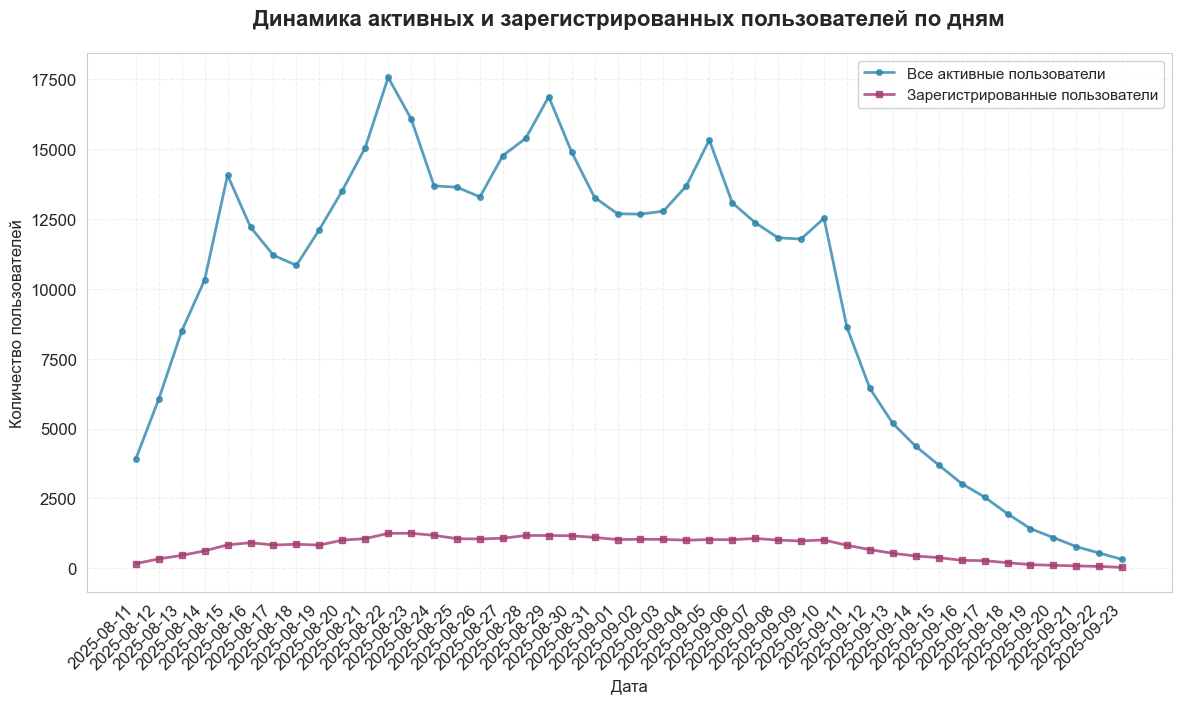

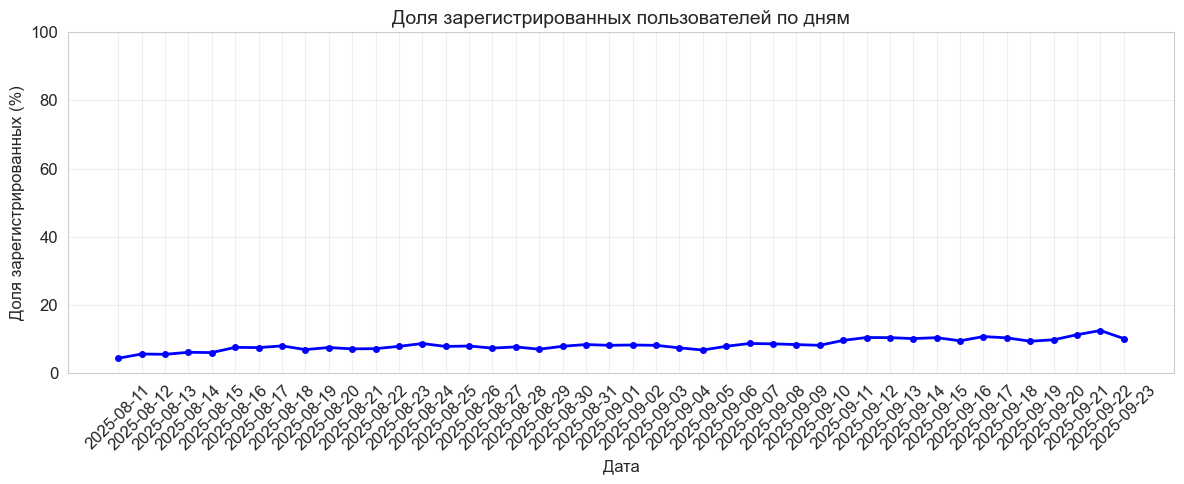

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Отфильтруем зарегистрированных пользователей
registered_df = sessions_history[sessions_history['registration_flag'] == 1]

# Затем посчитаем по дням
daily_total = sessions_history.groupby('session_date')['user_id'].nunique().reset_index()
daily_total.columns = ['session_date', 'total_users']

daily_registered = registered_df.groupby('session_date')['user_id'].nunique().reset_index()
daily_registered.columns = ['session_date', 'registered_users']

# Объединяем результаты
daily_stats = pd.merge(daily_total, daily_registered, on='session_date', how='left')
daily_stats['registered_users'] = daily_stats['registered_users'].fillna(0).astype(int)

# Рассчитываем долю зарегистрированных пользователей (в процентах)
daily_stats['registration_rate'] = (daily_stats['registered_users'] / daily_stats['total_users'] * 100).fillna(0)

# Строим графики

plt.figure(figsize=(14, 7))

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Построение графиков
plt.plot(daily_stats['session_date'], daily_stats['total_users'], 
         marker='o', linewidth=2, markersize=4, 
         label='Все активные пользователи', color='#2E86AB', alpha=0.8)

plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         marker='s', linewidth=2, markersize=4, 
         label='Зарегистрированные пользователи', color='#A23B72', alpha=0.8)

# Добавление аннотаций и форматирование
plt.title('Динамика активных и зарегистрированных пользователей по дням', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')

# Строим отдельный линейный график доли зарегистрированных пользователей

plt.figure(figsize=(12, 5))

plt.plot(daily_stats['session_date'], daily_stats['registration_rate'], 
         marker='o', linewidth=2, markersize=4, color='blue')

plt.title('Доля зарегистрированных пользователей по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля зарегистрированных (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках пректа проанализируем число просмотренных страниц во время первых сессий пользователей. Найдием количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.


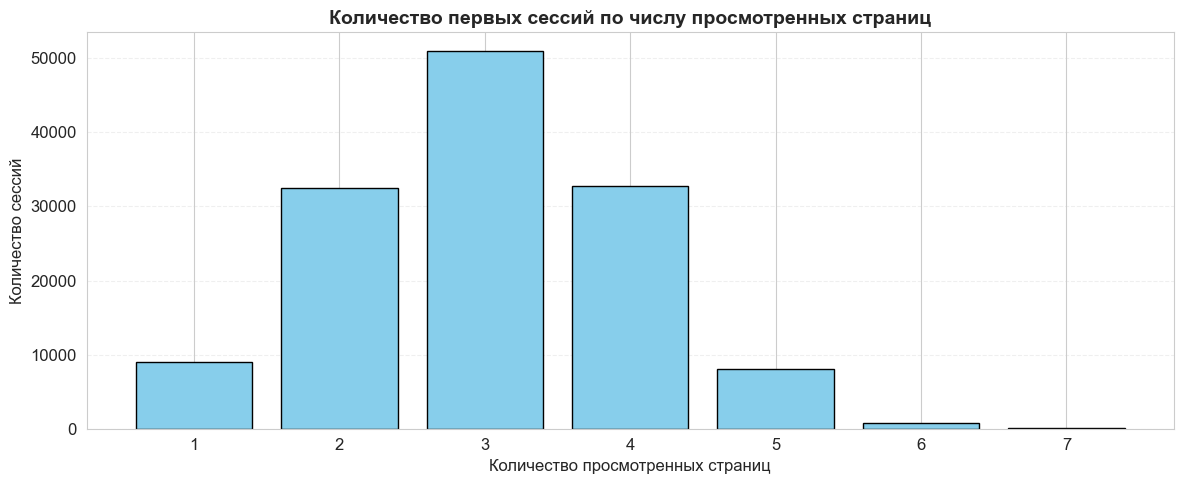

In [35]:

# Отбираем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Группируем по количеству страниц
page_counts = first_sessions.groupby('page_counter').size()

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 5))
plt.bar(page_counts.index, page_counts.values, color='skyblue', edgecolor='black')

# Добавляем заголовок и подписи
plt.title('Количество первых сессий по числу просмотренных страниц', fontsize=14, fontweight='bold')
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)

# Добавляем сетку 
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# Оптимизируем отображение оси X
plt.xticks(range(min(page_counts.index), max(page_counts.index) + 1, 
                  max(1, (max(page_counts.index) - min(page_counts.index)) // 10)))

plt.tight_layout()
plt.show()


#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

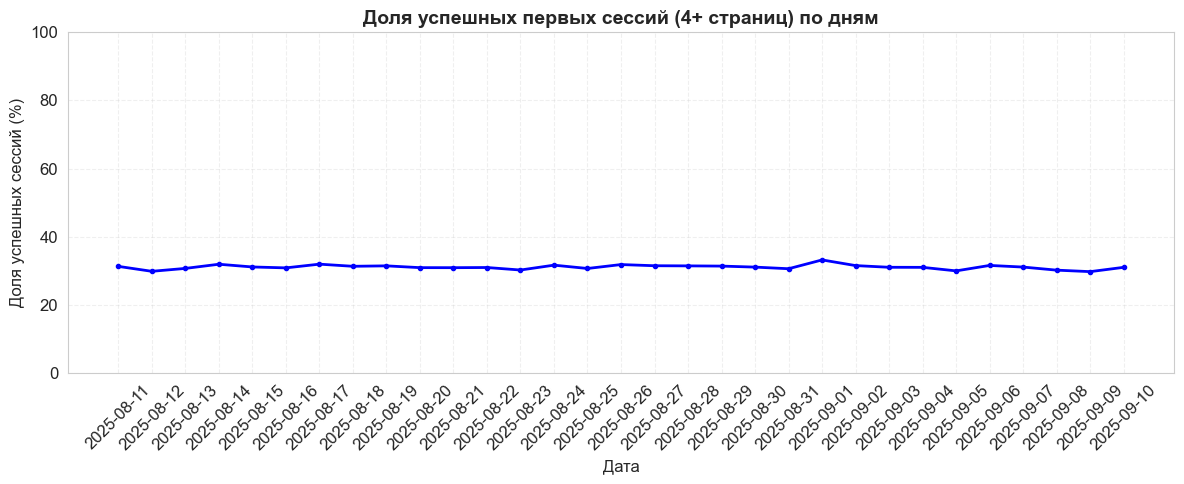

Средняя доля успешных сессий: 31.1%


In [36]:
# Создаем столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Отбираем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Группируем по дням и считаем долю успешных сессий
daily_stats = first_sessions.groupby('session_date').agg(
    total=('good_session', 'count'),
    good=('good_session', 'sum')
)
daily_stats['good_rate'] = daily_stats['good'] / daily_stats['total'] * 100

# Строим график
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats['good_rate'], 'b-o', linewidth=2, markersize=3)

# Настройки
plt.title('Доля успешных первых сессий (4+ страниц) по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных сессий (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Выводим статистику
print(f"Средняя доля успешных сессий: {daily_stats['good_rate'].mean():.1f}%")

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
 Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Зададим параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [38]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(3761 / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. 

In [39]:
# Загружаем датафрейм
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [40]:
# Рассчитываем количество уникальных пользователей в каждой группе
result = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(result)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


Группа A: 1477 пользователей
Группа B: 1466 пользователей
Процентная разница: 0.74%


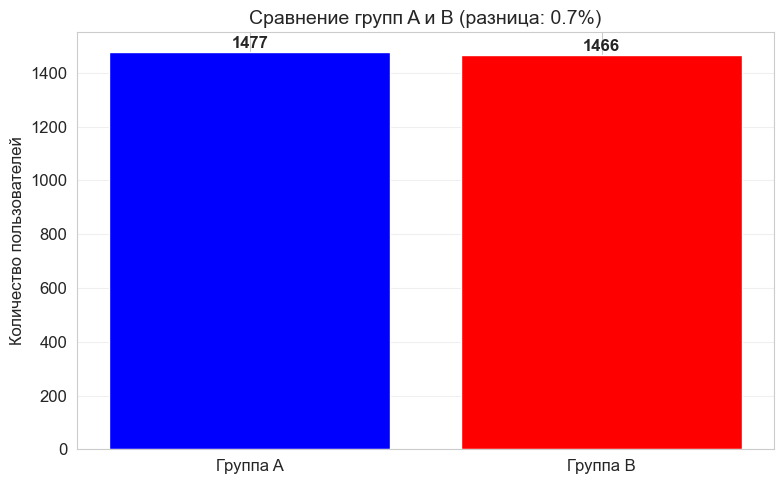

In [41]:
# Расчет количества пользователей по группам
group_counts = sessions_test_part.groupby('test_group')['user_id'].nunique()
count_A = group_counts['A']
count_B = group_counts['B']

# Расчет процентной разницы
percent_diff = 100 * abs(count_A - count_B) / count_A

print(f"Группа A: {count_A} пользователей")
print(f"Группа B: {count_B} пользователей")
print(f"Процентная разница: {percent_diff:.2f}%")

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar(['Группа A', 'Группа B'], [count_A, count_B], color=['blue', 'red'])
plt.title(f'Сравнение групп A и B (разница: {percent_diff:.1f}%)')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
plt.text(0, count_A + max(count_A, count_B)*0.01, str(count_A), ha='center', fontweight='bold')
plt.text(1, count_B + max(count_A, count_B)*0.01, str(count_B), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [42]:
# Получаем списки уникальных пользователей в каждой группе
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())

# Находим пересечение пользователей
intersection = users_A.intersection(users_B)

# Количество пересекающихся пользователей
intersection_count = len(intersection)

print(f"Количество пользователей в обеих группах одновременно: {intersection_count}")


Количество пользователей в обеих группах одновременно: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.



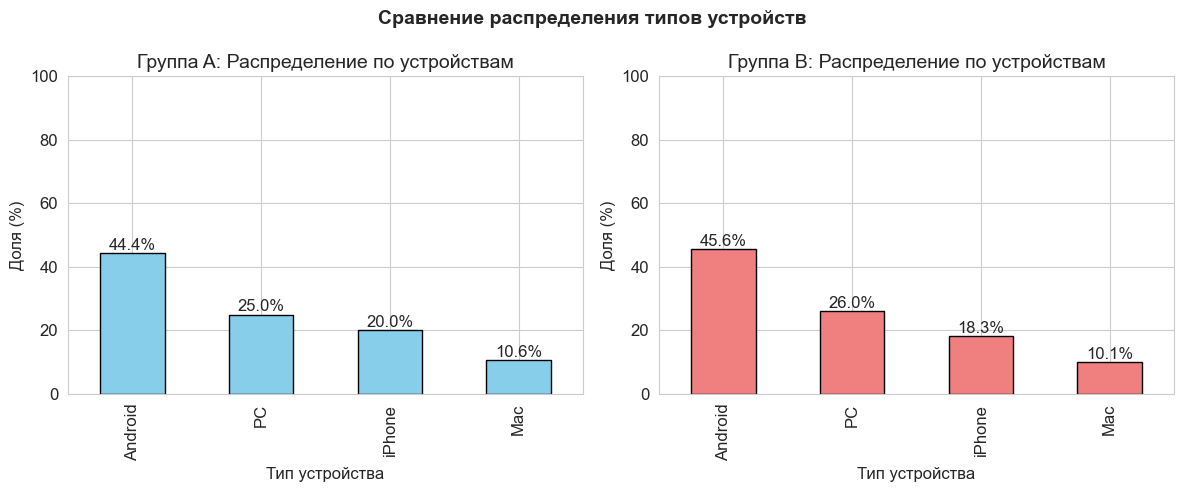

In [43]:
# Получаем уникальных пользователей с их устройством
user_device = sessions_test_part.groupby('user_id').agg({
    'device': 'first',
    'test_group': 'first'
}).reset_index()

# Считаем распределение по группам
device_dist_A = user_device[user_device['test_group'] == 'A']['device'].value_counts(normalize=True) * 100
device_dist_B = user_device[user_device['test_group'] == 'B']['device'].value_counts(normalize=True) * 100

# Строим диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

device_dist_A.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Группа A: Распределение по устройствам')
ax1.set_xlabel('Тип устройства')
ax1.set_ylabel('Доля (%)')
ax1.set_ylim(0, 100)
for i, v in enumerate(device_dist_A):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center')

device_dist_B.plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Группа B: Распределение по устройствам')
ax2.set_xlabel('Тип устройства')
ax2.set_ylabel('Доля (%)')
ax2.set_ylim(0, 100)
for i, v in enumerate(device_dist_B):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.suptitle('Сравнение распределения типов устройств', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.


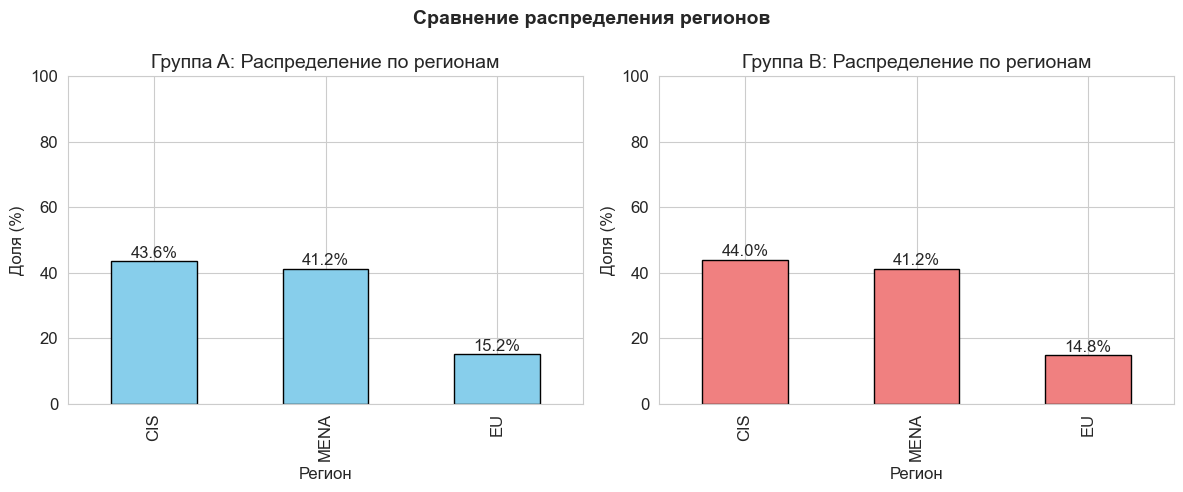

In [44]:
# Получаем уникальных пользователей с их регионом
user_region = sessions_test_part.groupby('user_id').agg({
    'region': 'first',
    'test_group': 'first'
}).reset_index()

# Считаем распределение по группам
region_dist_A = user_region[user_region['test_group'] == 'A']['region'].value_counts(normalize=True) * 100
region_dist_B = user_region[user_region['test_group'] == 'B']['region'].value_counts(normalize=True) * 100

# Строим диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

region_dist_A.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Группа A: Распределение по регионам')
ax1.set_xlabel('Регион')
ax1.set_ylabel('Доля (%)')
ax1.set_ylim(0, 100)
for i, v in enumerate(region_dist_A):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center')

region_dist_B.plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Группа B: Распределение по регионам')
ax2.set_xlabel('Регион')
ax2.set_ylabel('Доля (%)')
ax2.set_ylim(0, 100)
for i, v in enumerate(region_dist_B):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.suptitle('Сравнение распределения регионов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

В двух иследуемых для проведения А/В теста группах различий практически не выявлено. Так количество участников группы А отличается от группы В менее чем на один процент `(0,7%)`. Кроме этого прересечения пользователей тестовой и контрольной групп `не установлено`. В группах сохраняется равномерное распределение пользователей по используемым устройствам и регионам. На основе этого делаем вывод: `Для данных групп проведение А/В теста корректно`.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [45]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [46]:
# Создаем столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

В нашем случае нулевая гипотеза будес сформулирована следующим образом: `"Количество просмотренных страниц за первую сессию не измениться"`, тогда альтернативная гипотеза будет сформулирована так: `" Количество просмотренных страниц за первую сессию измениться"`.  Прокси-метрикой в данном эксперементе могло бы стать `время проведенное пользователем на сайте`. Барерную метрику можно было бы определить как `количество пользователей оформивших подписку`.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразим на экране.

In [47]:
#  Отбираем первые сессии для каждого пользователя
first_sessions = sessions_test[sessions_test['session_number'] == 1]

#  Рассчитываем долю успешных первых сессий по группам
success_rate_by_group = first_sessions.groupby('test_group')['good_session'].agg(['mean', 'count']).round(4)
success_rate_by_group.columns = ['success_rate', 'sessions_count']
success_rate_by_group['success_rate_pct'] = (success_rate_by_group['success_rate'] * 100).round(2)

#  Извлекаем значения для групп A и B
rate_A = success_rate_by_group.loc['A', 'success_rate']
rate_B = success_rate_by_group.loc['B', 'success_rate']
count_A = success_rate_by_group.loc['A', 'sessions_count']
count_B = success_rate_by_group.loc['B', 'sessions_count']

#  Рассчитываем разницу
difference = rate_B - rate_A
relative_difference = (rate_B - rate_A) / rate_A * 100

#  Выводим результаты
print(f"\nГруппа A (контроль):")
print(f"  - Количество первых сессий: {count_A}")
print(f"  - Доля успешных сессий: {rate_A:.4f} ({rate_A*100:.2f}%)")

print(f"\nГруппа B (тест):")
print(f"  - Количество первых сессий: {count_B}")
print(f"  - Доля успешных сессий: {rate_B:.4f} ({rate_B*100:.2f}%)")

print(f"  - Относительная разница: {relative_difference:.2f}%")





Группа A (контроль):
  - Количество первых сессий: 15162
  - Доля успешных сессий: 0.3157 (31.57%)

Группа B (тест):
  - Количество первых сессий: 15416
  - Доля успешных сессий: 0.3147 (31.47%)
  - Относительная разница: -0.32%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведем на экран полученное значение p-value и  выводы о статистической значимости. Уровень значимости в эксперименте был выбран на уровне 0.05.

In [48]:
from statsmodels.stats.proportion import proportions_ztest

#  Получаем данные для групп A и B
success_A = first_sessions[first_sessions['test_group'] == 'A']['good_session'].sum()
total_A = first_sessions[first_sessions['test_group'] == 'A']['good_session'].count()

success_B = first_sessions[first_sessions['test_group'] == 'B']['good_session'].sum()
total_B = first_sessions[first_sessions['test_group'] == 'B']['good_session'].count()

#  Рассчитываем доли
rate_A = success_A / total_A
rate_B = success_B / total_B

#  Двухвыборочный z-тест для пропорций

print("МЕТОД  Двухвыборочный z-тест для пропорций")

z_stat, p_value_ztest = proportions_ztest(
    count=[success_B, success_A],
    nobs=[total_B, total_A],
    alternative='two-sided'  # Двусторонняя проверка
)

print(f"P-value: {p_value_ztest:.6f}")

alpha = 0.05

print(f"\nУровень значимости (α): {alpha}")

# Используем p-value из z-теста 
p_value = p_value_ztest

if p_value < alpha:
    print(f"\n✓ P-value ({p_value:.6f}) < α ({alpha})")
    print(f"\n Вывод: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА")
    print(f"  Отвергаем нулевую гипотезу о равенстве долей.")
    print(f"  Изменение в метрике не случайно и с вероятностью {((1-p_value)*100):.2f}% отражает реальный эффект.")
    
    if diff > 0:
        print(f"  Группа B показывает значительно лучший результат (+{diff*100:.2f} п.п.).")
    else:
        print(f"  Группа B показывает значительно худший результат ({diff*100:.2f} п.п.).")
else:
    print(f"\n✗ P-value ({p_value:.6f}) >= α ({alpha})")
    print(f"\n Вывод: Разница СТАТИСТИЧЕСКИ НЕ ЗНАЧИМА")
    print(f"  Не отвергаем нулевую гипотезу о равенстве долей.")
    print(f"  Наблюдаемое изменение может быть объяснено случайной вариацией.")
    print(f"  У нас нет достаточных оснований считать, что тестовое изменение повлияло на метрику.")



МЕТОД  Двухвыборочный z-тест для пропорций
P-value: 0.843295

Уровень значимости (α): 0.05

✗ P-value (0.843295) >= α (0.05)

 Вывод: Разница СТАТИСТИЧЕСКИ НЕ ЗНАЧИМА
  Не отвергаем нулевую гипотезу о равенстве долей.
  Наблюдаемое изменение может быть объяснено случайной вариацией.
  У нас нет достаточных оснований считать, что тестовое изменение повлияло на метрику.


#### 4.5. Вывод по результатам A/B-эксперимента


На основе анализа проведенного А/В эксперемента по изучению влияния нового алгоритма предложений контента для пользователей мы пришли к таким результатам. Опреледелились с целевой метрикой `"Доля успешных первых сессий"`. определили количество необходимых пользователей для тестовых групп: `3761` для каждой группы. Также вычислили продолжительность проведения теста- `один день`. Внедрение нового алгоритма незначительно повлияло на изменения разница в группах сотавила `0.32 %`. P-value = `0.843295`, при уровне статистической значимости `0.05`. На основании этого можно сделать вывод о том, что у нас нет оснований считать, что тестовое изменение повлияло на ключевую метрику. Так как у нас нет данных для проверки прокси- и бареных метрик, считаем `что внедрение новвоведения нецелесообразно`.